# 🌿 PlantCare AI — Notebook de bout en bout

Projet *MSI-5-26-BD* — **Tina · Kaavya · Nathan · Thomas**

Ce notebook rejoue **tout le pipeline** du POC, du jeu de données simulé jusqu'aux
quatre options d'IA (A/B/C/D). Il est organisé en parties indépendantes : **chacun peut
aller directement à sa partie et la modifier sans casser les autres**, tant que
la partie *0 — Données* a été exécutée au moins une fois.

| Partie | Option | Responsable | Ce qu'elle fait |
|---|---|---|---|
| 0 | — | *(commun)* | génère / charge les données simulées |
| 1 | Structurer | *Thomas* | Datalake |
| A | Conseiller | *Kaavya* | conseil en langage naturel — Gemini + secours local |
| B | Reconnaître | *Tina* | espèce à partir d'une photo — MobileNetV2 fine-tuné |
| C | Anticiper | *Kaavya* | verdict d'arrosage — RandomForest + SHAP |
| D | Santé | *Nathan* | diagnostic de maladies à partir d'une photo — API plant.health (Kindwise) + repli stub |
| — | Synthèse | *(commun)* | bilan des métriques, critères d'acceptation M1 |


Ce notebook est le pendant pédagogique des scripts `ml/*.py` et `src/plantcare/`,
qui restent la version "production" (appelée par l'API FastAPI). Voir le `README.md`
du dépôt pour l'architecture Clean Architecture complète.

## Setup — imports, chemins, environnement

Cette cellule doit tourner **en premier**, quelle que soit la partie sur laquelle vous travaillez.


In [1]:
from __future__ import annotations

import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Le notebook vit dans notebooks/, le code applicatif dans src/ et ml/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (ROOT / "src" / "plantcare").exists(), f"Racine du projet introuvable depuis {ROOT}"
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "ml"))

DATA = ROOT / "data"
ARTIFACTS = ROOT / "ml" / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / ".env")
except ImportError:
    print("python-dotenv absent : GEMINI_API_KEY doit être exporté manuellement pour la partie A.")

# Palette fixe (identité de catégorie, jamais recyclée) — cf. skill dataviz
PALETTE_VERDICT = {
    "ne_pas_arroser": "#2E8B57",          # vert — aucune action requise
    "verifier_prochainement": "#E1A100",  # ambre — à surveiller
    "arroser_maintenant": "#D64550",      # rouge — action requise
}
PALETTE_2 = ["#3B6FA0", "#D68A3B"]  # baseline vs fine-tuned / modèle vs baseline
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Racine projet :", ROOT)


Racine projet : /Users/kaavya/Downloads/Projet Plant Care AI/plantcare-ai


## Partie 0 — Données

*(commune à toute l'équipe — à modifier seulement si vous changez le schéma des données)*

Génère un jeu de données simulé cohérent (utilisateurs, plantes, mesures capteurs,
météo, historique de soins) via `ml/generate_synthetic_data.py`. La logique
d'arrosage "vérité terrain" est déterministe-bruitée : un RandomForest doit
pouvoir la retrouver (cf. critère F1 > 0.70 de la partie C).


In [2]:
from generate_synthetic_data import generer, ESPECES, VERDICTS

dataset_path = DATA / "dataset_arrosage.csv"
if dataset_path.exists():
    print("Données déjà présentes dans data/, chargement direct.")
    df_arrosage = pd.read_csv(dataset_path)
    df_especes = pd.read_csv(DATA / "especes.csv")
else:
    print("Génération des données simulées...")
    tables = generer()
    DATA.mkdir(parents=True, exist_ok=True)
    for name, df in tables.items():
        df.to_csv(DATA / f"{name}.csv", index=False)
    df_arrosage = tables["dataset_arrosage"]
    df_especes = tables["especes"]

print(df_arrosage.shape, "lignes x colonnes")
df_arrosage.head()


Données déjà présentes dans data/, chargement direct.
(9160, 9) lignes x colonnes


,espece_id,taille_pot,sol,temperature,lux,humidite_air,seuil_sol_sec,jours_dernier_arrosage,verdict
0,6,18,54.108471,12.244824,74.455123,71.534085,40,8,ne_pas_arroser
1,6,18,39.747983,17.734780,619.849494,79.333503,40,7,ne_pas_arroser
2,6,18,47.012640,17.703538,492.187696,58.493409,40,6,ne_pas_arroser
3,6,18,39.251111,21.075688,229.767614,84.670496,40,4,ne_pas_arroser
4,6,18,34.717997,24.661546,491.361016,74.952791,40,8,verifier_prochainement


### Aperçu rapide — distribution des verdicts d'arrosage

Un seul axe, une couleur par catégorie fixée par son sens (vert = rien à faire,
ambre = à surveiller, rouge = à arroser), valeurs affichées directement sur les barres.


/var/folders/pl/mkqqx8r16rxb8k8xmc60m6l40000gn/T/ipykernel_34680/253348571.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=15, ha="right")


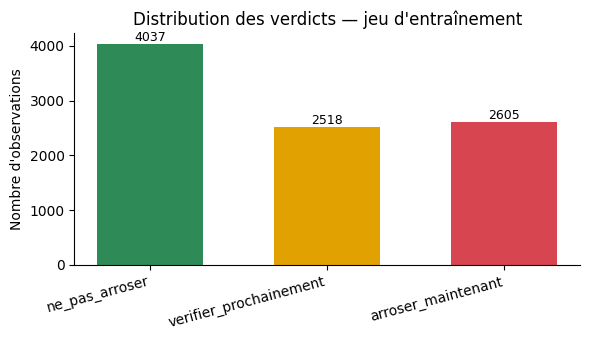

In [3]:
counts = df_arrosage["verdict"].value_counts().reindex(VERDICTS)

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE_VERDICT[v] for v in counts.index], width=0.6)
ax.set_ylabel("Nombre d'observations")
ax.set_title("Distribution des verdicts — jeu d'entraînement")
ax.set_xticklabels(counts.index, rotation=15, ha="right")
for b in bars:
    ax.annotate(f"{int(b.get_height())}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## Partie C — Option "Anticiper" : verdict d'arrosage (RandomForest)

**Responsable : _(à compléter)_**

Objectif (cahier des charges M1) : **F1 macro > 0.70**, comparé à un baseline
`DummyClassifier` (réflexe *baseline-first*, cf. M2/R9). Interprétabilité via SHAP.

Miroir notebook de `ml/train_watering.py` — toute modif substantielle doit être
reportée dans ce script pour que `make train-c` reste la version "officielle".


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

FEATURES = ["espece_id", "taille_pot", "sol", "temperature", "lux",
            "humidite_air", "seuil_sol_sec", "jours_dernier_arrosage"]
TARGET = "verdict"

X, y = df_arrosage[FEATURES], df_arrosage[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# --- baseline ----------------------------------------------------------
baseline = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
f1_base = f1_score(y_te, baseline.predict(X_te), average="macro")

# --- modèle --------------------------------------------------------------
clf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)

metrics_c = dict(
    accuracy=accuracy_score(y_te, pred),
    precision_macro=precision_score(y_te, pred, average="macro"),
    recall_macro=recall_score(y_te, pred, average="macro"),
    f1_macro=f1_score(y_te, pred, average="macro"),
    f1_baseline=f1_base,
)

for k, v in metrics_c.items():
    print(f"{k:16s}: {v:.4f}")
print()
print(classification_report(y_te, pred))

seuil = 0.70
ok_c = metrics_c["f1_macro"] > seuil
print(f"Critère d'acceptation F1 > {seuil} : {'OK' if ok_c else 'ECHEC'} "
      f"(gain sur baseline : +{metrics_c['f1_macro'] - f1_base:.3f})")


accuracy        : 0.8769
precision_macro : 0.8678
recall_macro    : 0.8666
f1_macro        : 0.8672
f1_baseline     : 0.2039

                        precision    recall  f1-score   support

    arroser_maintenant       0.90      0.90      0.90       651
        ne_pas_arroser       0.92      0.93      0.92      1009
verifier_prochainement       0.78      0.78      0.78       630

              accuracy                           0.88      2290
             macro avg       0.87      0.87      0.87      2290
          weighted avg       0.88      0.88      0.88      2290

Critère d'acceptation F1 > 0.7 : OK (gain sur baseline : +0.663)


### Interprétabilité — importance des variables (SHAP)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


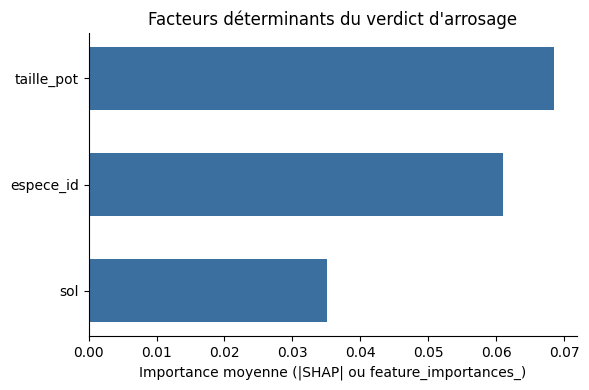

In [5]:
try:
    import shap
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(X_te.iloc[:200])
    arr = np.array(sv)
    imp = np.abs(arr).mean(axis=tuple(range(arr.ndim - 1)))
    importances = sorted(zip(FEATURES, imp.tolist()), key=lambda t: t[1], reverse=True)
except Exception as e:
    print("SHAP indisponible, repli sur feature_importances_ :", e)
    importances = sorted(zip(FEATURES, clf.feature_importances_.tolist()),
                          key=lambda t: t[1], reverse=True)

labels, vals = zip(*importances)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(labels[::-1], vals[::-1], color=PALETTE_2[0], height=0.6)
ax.set_xlabel("Importance moyenne (|SHAP| ou feature_importances_)")
ax.set_title("Facteurs déterminants du verdict d'arrosage")
plt.tight_layout()
plt.show()


In [6]:
import joblib

joblib.dump(clf, ARTIFACTS / "watering_rf.joblib")
(ARTIFACTS / "watering_meta.json").write_text(json.dumps(
    dict(features=FEATURES, classes=list(clf.classes_), metrics=metrics_c,
         importances=[list(t) for t in importances]), indent=2))
print("Modèle sauvegardé dans", ARTIFACTS.resolve())


Modèle sauvegardé dans /Users/kaavya/Downloads/Projet Plant Care AI/plantcare-ai/ml/artifacts


## Partie B — Option "Reconnaître" : espèce à partir d'une photo (MobileNetV2)

**Responsable : _(à compléter)_**

> ⚠️ Point de vigilance soutenance : ici on **fine-tune** (on met à jour des
> poids), on ne fait pas que de l'inférence.

Attendu : démontrer une **amélioration** après fine-tuning par rapport au
pré-entraîné brut (baseline-first). `data/plantnet_subset/` contient désormais
un vrai sous-ensemble PlantNet-300K (8 espèces, ~100 photos chacune, récupérées
en streaming ciblé sans télécharger les 32 Go — cf. `SETUP_MANUEL.md`). Si ce
dossier venait à manquer, un micro-jeu synthétique de secours est généré
uniquement pour prouver que la boucle d'entraînement tourne.

Miroir notebook de `ml/train_vision.py` (`python ml/train_vision.py --epochs 3`).


In [7]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms

DATA_DIR_VISION = DATA / "plantnet_subset"
EPOCHS = 3          # augmentez une fois le vrai jeu PlantNet en place
LR = 1e-3

def _fabriquer_jeu_synthetique(root: Path, classes=4, par_classe=24):
    from PIL import Image
    root.mkdir(parents=True, exist_ok=True)
    couleurs = [(60, 160, 70), (40, 120, 160), (170, 120, 60), (150, 70, 150)]
    for c in range(classes):
        d = root / f"espece_demo_{c}"
        d.mkdir(exist_ok=True)
        base = np.array(couleurs[c % len(couleurs)])
        for i in range(par_classe):
            noise = np.random.default_rng(c * 100 + i).integers(-30, 30, (64, 64, 3))
            arr = np.clip(base + noise, 0, 255).astype("uint8")
            Image.fromarray(arr).save(d / f"img_{i}.png")
    print(f"[demo] micro-jeu synthétique créé dans {root} ({classes} classes) "
          "— À REMPLACER par PlantNet.")

if not DATA_DIR_VISION.exists() or not any(DATA_DIR_VISION.iterdir()):
    _fabriquer_jeu_synthetique(DATA_DIR_VISION)

tf = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
ds = datasets.ImageFolder(str(DATA_DIR_VISION), transform=tf)
classes_vision = ds.classes
n_val = max(1, int(0.25 * len(ds)))
train_ds, val_ds = random_split(ds, [len(ds) - n_val, n_val],
                                generator=torch.Generator().manual_seed(42))
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=16)
print(f"{len(ds)} images, {len(classes_vision)} classes : {classes_vision}")


800 images, 8 classes : ['Calendula_officinalis', 'Cirsium_vulgare', 'Humulus_lupulus', 'Hypericum_perforatum', 'Melilotus_albus', 'Pelargonium_graveolens', 'Sedum_album', 'Tradescantia_fluminensis']


In [8]:
def build_net():
    net = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    net.classifier[1] = nn.Linear(net.classifier[1].in_features, len(classes_vision))
    return net

def accuracy(net):
    net.eval()
    ok = tot = 0
    with torch.no_grad():
        for x, y in val_dl:
            p = net(x).argmax(1)
            ok += (p == y).sum().item()
            tot += y.numel()
    return ok / max(tot, 1)

# --- BASELINE : tête non entraînée (pré-entraîné brut) --------------------
baseline_net = build_net()
acc_baseline = accuracy(baseline_net)

# --- FINE-TUNING : on entraîne la tête + dernières couches -----------------
net = build_net()
for p in net.features[:-3].parameters():
    p.requires_grad = False
opt = optim.Adam([p for p in net.parameters() if p.requires_grad], lr=LR)
crit = nn.CrossEntropyLoss()
for ep in range(EPOCHS):
    net.train()
    for x, y in train_dl:
        opt.zero_grad()
        loss = crit(net(x), y)
        loss.backward()
        opt.step()
    print(f"  epoch {ep + 1}/{EPOCHS}  val_acc={accuracy(net):.3f}")

acc_ft = accuracy(net)
print(f"\nbaseline (pré-entraîné brut) : {acc_baseline:.3f}")
print(f"après fine-tuning            : {acc_ft:.3f}")
print(f"amélioration                 : {'OUI' if acc_ft > acc_baseline else 'NON'} "
      f"({acc_ft - acc_baseline:+.3f})")


  epoch 1/3  val_acc=0.815
  epoch 2/3  val_acc=0.835
  epoch 3/3  val_acc=0.795

baseline (pré-entraîné brut) : 0.145
après fine-tuning            : 0.795
amélioration                 : OUI (+0.650)


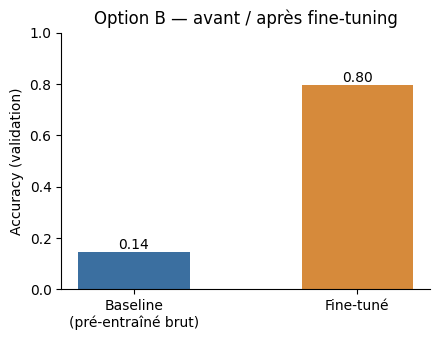

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
labels_b = ["Baseline\n(pré-entraîné brut)", "Fine-tuné"]
vals_b = [acc_baseline, acc_ft]
bars = ax.bar(labels_b, vals_b, color=PALETTE_2, width=0.5)
ax.set_ylabel("Accuracy (validation)")
ax.set_ylim(0, 1)
ax.set_title("Option B — avant / après fine-tuning")
for b, v in zip(bars, vals_b):
    ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom")
plt.tight_layout()
plt.show()


In [10]:
torch.save(net.state_dict(), ARTIFACTS / "vision_mobilenet.pt")
(ARTIFACTS / "vision_classes.json").write_text(json.dumps(classes_vision))
print("Modèle vision sauvegardé dans", ARTIFACTS.resolve())


Modèle vision sauvegardé dans /Users/kaavya/Downloads/Projet Plant Care AI/plantcare-ai/ml/artifacts


## Partie A — Option "Conseiller" : conseil en langage naturel (Gemini + secours local)

**Responsable : Kaavya

Passerelle **abstraite** devant le LLM (cf. M2/R3 : mitigation du risque
d'indisponibilité de Gemini). `obtenir_gateway()` choisit automatiquement :
clé API Gemini (AI Studio) > Vertex AI > **gabarit local** (aucun réseau).
Ainsi la fonctionnalité ne dépend jamais entièrement d'un tiers (cf. M6).

RGPD : le payload envoyé au LLM ne contient que des données publiques ou
pseudonymisées (fiche d'espèce, météo, verdict d'arrosage) — jamais de donnée
personnelle brute.

Aucune clé requise pour exécuter cette partie : sans `GEMINI_API_KEY` valide,
le gabarit local prend le relais automatiquement et le notebook reste exécutable
de bout en bout hors ligne.


In [ ]:
from plantcare.adapters.llm_gateway import obtenir_gateway, PayloadConseil

gateway = obtenir_gateway()
print("Gateway sélectionnée :", type(gateway).__name__)

# Exemple pseudonymisé (aucune donnée personnelle) --------------------------
payload = PayloadConseil(
    espece="Monstera deliciosa",
    lumiere="indirecte vive",
    temperature_jour=27.0,
    humidite_air_jour=45.0,
    verdict_arrosage="verifier_prochainement",
)

conseil = gateway.conseiller(payload)
print("\nSource :", conseil.source)
print("Conseil :", conseil.texte)


### Comparaison — gabarit local explicite

Utile pour visualiser le comportement de repli même si une clé Gemini valide est configurée.


In [ ]:
from plantcare.adapters.llm_gateway import GabaritLocalGateway

conseil_local = GabaritLocalGateway().conseiller(payload)
print("Source :", conseil_local.source)
print("Conseil :", conseil_local.texte)


## Partie D — Option "Santé" : diagnostic à partir d'une photo (plant.health / Kindwise)

**Responsable : Nathan**

Passerelle **abstraite** devant l'API tierce plant.health (Kindwise Plant.id v3) —
même pattern que la passerelle LLM de la partie A. `obtenir_plant_health_gateway()`
choisit automatiquement :

- `PlantHealthAPIGateway` si `PLANT_HEALTH_API_KEY` est présente dans l'environnement
  (appel réseau réel vers plant.health) ;
- `PlantHealthStubGateway` sinon (repli local, résultat vide, jamais d'erreur).

RGPD : la photo ne quitte le serveur vers un tiers **que si** l'utilisateur soumet une
image **et** que la clé API est configurée (cf. `README.md`). Elle est prétraitée
localement (redimensionnement, suppression des métadonnées EXIF) avant tout envoi.

Miroir notebook de `src/plantcare/adapters/plant_health_gateway.py`, appelé en
production par la route `POST /api/v1/sante` de l'API FastAPI (elle-même utilisée par
l'onglet **🔬 Santé (D)** du dashboard).

Aucune clé requise pour exécuter cette partie : sans `PLANT_HEALTH_API_KEY` valide, le
repli stub prend le relais automatiquement et le notebook reste exécutable de bout en
bout hors ligne.

In [ ]:
from plantcare.adapters.plant_health_gateway import (
    PlantHealthAPIGateway,
    PlantHealthStubGateway,
    obtenir_plant_health_gateway,
)

plant_health_gateway = obtenir_plant_health_gateway()
print("Gateway sélectionnée :", type(plant_health_gateway).__name__)
if isinstance(plant_health_gateway, PlantHealthStubGateway):
    print("Aucune PLANT_HEALTH_API_KEY détectée -> repli local (résultat vide, pas d'appel réseau).")
else:
    print("PLANT_HEALTH_API_KEY détectée -> l'appel suivant contacte réellement plant.health.")

### Exemple — analyse d'une photo

En production, la photo vient de l'upload utilisateur (`UploadFile` de FastAPI) ; ici on
lit simplement les octets d'un fichier de démo pour illustrer le contrat
`analyser(image_bytes) -> AnalyseSante`. On réutilise si possible une image du
sous-ensemble PlantNet (`data/plantnet_subset/`, cf. partie B) ; à défaut une image
factice est générée en mémoire, pour que cette partie reste exécutable même si l'on
saute directement à la partie D après la partie 0.

In [ ]:
IMG_DIR_SANTE = DATA / "plantnet_subset"
image_demo = next(
    (p for pattern in ("*.jpg", "*.jpeg", "*.png") for p in IMG_DIR_SANTE.rglob(pattern)),
    None,
) if IMG_DIR_SANTE.exists() else None

if image_demo is not None:
    image_bytes = image_demo.read_bytes()
    source_image = str(image_demo.relative_to(ROOT))
else:
    from io import BytesIO
    from PIL import Image
    buf = BytesIO()
    Image.new("RGB", (224, 224), (60, 160, 70)).save(buf, format="JPEG")
    image_bytes = buf.getvalue()
    source_image = "image factice (aucune image PlantNet trouvée)"

analyse = plant_health_gateway.analyser(image_bytes)

print("Image analysée :", source_image)
print("Est saine :", analyse.est_saine)
print("Probabilité de santé :", analyse.probabilite_sante)
if analyse.suggestions:
    for s in analyse.suggestions:
        print(f"\n- {s.nom} (probabilité {s.probabilite:.2f})")
        print(f"  {s.description}")
        if s.traitement:
            print(f"  Traitement suggéré : {s.traitement}")
else:
    print("Aucune suggestion (repli stub, ou plante jugée saine).")

### Comparaison — repli stub explicite

Utile pour visualiser le comportement de repli même si une clé `PLANT_HEALTH_API_KEY`
valide est configurée (aucun appel réseau, résultat toujours vide mais jamais d'erreur).

In [ ]:
analyse_stub = PlantHealthStubGateway().analyser(image_bytes)
print("Source :", type(PlantHealthStubGateway()).__name__)
print("Est saine :", analyse_stub.est_saine)
print("Probabilité de santé :", analyse_stub.probabilite_sante)
print("Suggestions :", analyse_stub.suggestions)

## Synthèse — bilan des quatre options

Récapitulatif des métriques obtenues dans ce run, à comparer aux critères
d'acceptation M1 (F1 > 0.70 pour C, amélioration démontrée pour B, réponse
garantie même hors ligne pour A, jamais d'erreur même sans clé pour D).

In [ ]:
bilan = pd.DataFrame([
    dict(option="C — Arrosage (RandomForest)", metrique="F1 macro",
         valeur=round(metrics_c['f1_macro'], 3), baseline=round(metrics_c['f1_baseline'], 3),
         critere="> 0.70", ok=ok_c),
    dict(option="B — Vision (MobileNetV2)", metrique="Accuracy",
         valeur=round(acc_ft, 3), baseline=round(acc_baseline, 3),
         critere="fine-tuné > baseline", ok=acc_ft > acc_baseline),
    dict(option="A — Conseil (LLM)", metrique="Réponse générée",
         valeur=conseil.source, baseline="gabarit_local",
         critere="toujours une réponse", ok=bool(conseil.texte)),
    dict(option="D — Santé (plant.health)", metrique="Analyse retournée",
         valeur=type(plant_health_gateway).__name__, baseline="PlantHealthStubGateway",
         critere="jamais d'erreur, même sans clé API", ok=analyse is not None),
])
bilan

### Prochaines étapes (à répartir en équipe)

- [ ] **Partie A** — brancher une vraie clé Gemini (`.env` → `GEMINI_API_KEY`), comparer avec/sans clé.
- [x] **Partie B** — sous-ensemble PlantNet réel en place (8 espèces, 100 photos chacune) ; amélioration baseline → fine-tuning confirmée.
- [ ] **Partie C** — tester d'autres hyperparamètres RandomForest, comparer à un gradient boosting.
- [ ] **Partie D** — tester avec une vraie clé `PLANT_HEALTH_API_KEY` sur une photo de plante malade réelle, et comparer les suggestions retournées à un diagnostic humain.
- [ ] **Synthèse** — brancher MLflow (`make pipeline` / serveur MLflow local) pour tracer tous les runs automatiquement.

Chaque partie peut être ré-exécutée indépendamment tant que la **Partie 0** a tourné une fois.